# 1. Setup & Imports

In [17]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Display settings (optional, for readability)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


# 2. Load the Data

In [18]:
# Load datasets
# Each dataset represents a different aspect of movie data

expert_df = pd.read_csv("../../Metacritic dataset/ExpertReviews.csv")

user_df = pd.read_csv(
    "../../Metacritic dataset/UserReviews.csv",
    low_memory=False  # avoids dtype inference warnings
)

meta_df = pd.read_csv("../../Metacritic dataset/metaClean43Brightspace.csv")

sales_df = pd.read_csv("../../Metacritic dataset/sales.csv")


# 3. Data Sanity Check

## 3.1 Dataset Size

In [19]:
# Check number of rows and columns for each dataset
print("ExpertReviews:", expert_df.shape)
print("UserReviews:", user_df.shape)
print("Meta data:", meta_df.shape)
print("Sales data:", sales_df.shape)


ExpertReviews: (238973, 5)
UserReviews: (319662, 7)
Meta data: (11364, 13)
Sales data: (30612, 16)


## 3.2 Structure & Data Types

In [20]:
# Inspect structure and inferred data types
print("\nExpertReviews info:")
expert_df.info()

print("\nUserReviews info:")
user_df.info()

print("\nMeta data info:")
meta_df.info()

print("\nSales data info:")
sales_df.info()



ExpertReviews info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238973 entries, 0 to 238972
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   url       238973 non-null  object 
 1   idvscore  238971 non-null  float64
 2   reviewer  238971 non-null  object 
 3   dateP     238971 non-null  object 
 4   Rev       238971 non-null  object 
dtypes: float64(1), object(4)
memory usage: 9.1+ MB

UserReviews info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319662 entries, 0 to 319661
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   url        319662 non-null  object
 1   idvscore   316258 non-null  object
 2   reviewer   316255 non-null  object
 3   dateP      316249 non-null  object
 4   Rev        316249 non-null  object
 5   thumbsUp   316082 non-null  object
 6   thumbsTot  316086 non-null  object
dtypes: object(7)
memory usage: 17.1+ MB

Meta d

## 3.3 Missing Values Overview

In [21]:
# Percentage of missing values per column
print("\nExpertReviews missing %:")
print((expert_df.isna().mean() * 100).round(2))

print("\nUserReviews missing %:")
print((user_df.isna().mean() * 100).round(2))

print("\nMeta data missing %:")
print((meta_df.isna().mean() * 100).round(2))

print("\nSales data missing %:")
print((sales_df.isna().mean() * 100).round(2))



ExpertReviews missing %:
url         0.0
idvscore    0.0
reviewer    0.0
dateP       0.0
Rev         0.0
dtype: float64

UserReviews missing %:
url          0.00
idvscore     1.06
reviewer     1.07
dateP        1.07
Rev          1.07
thumbsUp     1.12
thumbsTot    1.12
dtype: float64

Meta data missing %:
url           0.00
title         0.00
studio        3.08
rating        9.39
runtime       2.24
cast         32.58
director      0.12
genre         0.18
summary      51.89
awards       61.40
metascore     0.00
userscore    18.52
RelDate       0.00
dtype: float64

Sales data missing %:
year                          0.00
release_date                  0.00
title                         0.03
genre                         5.57
international_box_office     29.52
domestic_box_office          61.18
worldwide_box_office         29.52
production_budget            85.37
Unnamed: 8                  100.00
opening_weekend              64.30
theatre_count                64.19
avg run per theatre   

# 4. Score Distributions

## Expert Scores

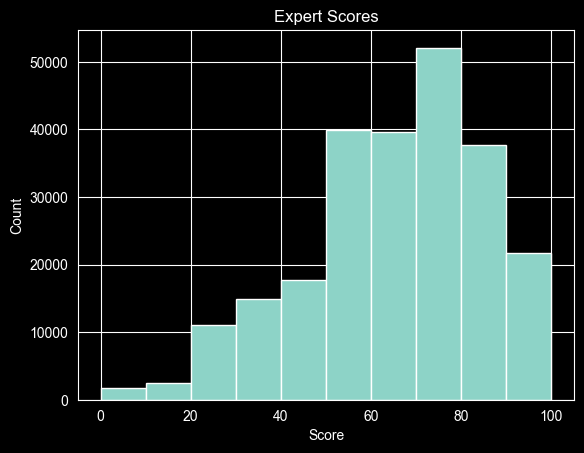

In [22]:
# Expert review scores
# Convert to numeric temporarily to avoid type issues (EDA-safe)
pd.to_numeric(expert_df["idvscore"], errors="coerce").hist()
plt.title("Expert Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()


## User Scores

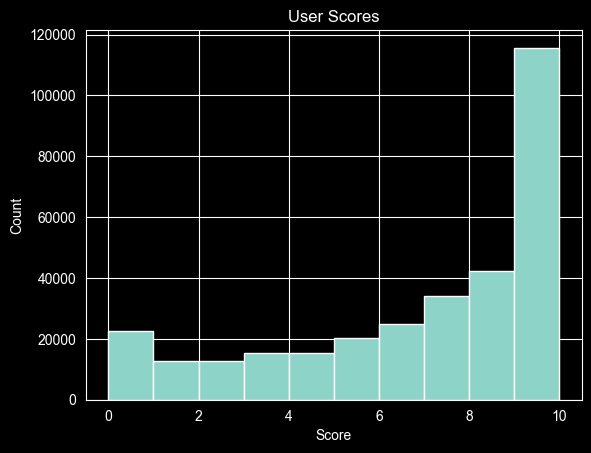

In [23]:
# User review scores
# Expected range: 1–10
pd.to_numeric(user_df["idvscore"], errors="coerce").hist()
plt.title("User Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()



## Metascore

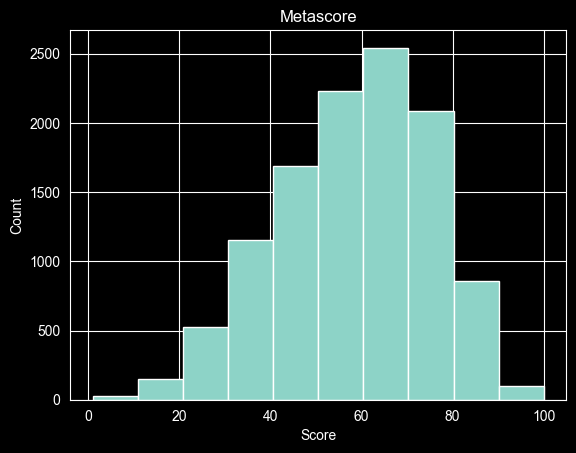

In [24]:
# Metascore distribution
# Expected range: 0–100
meta_df["metascore"].hist()
plt.title("Metascore")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()



## Sales


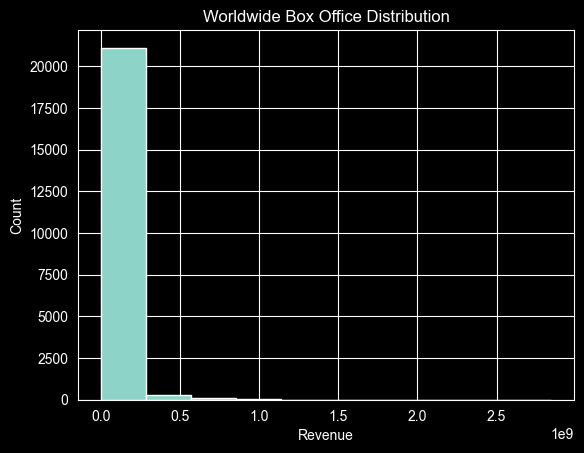

In [25]:
# Convert to numeric temporarily (EDA-safe)
# Worldwide Box Office Distribution
# Purpose: Check scale, skewness, and
# presence of extreme outliers

worldwide_revenue = pd.to_numeric(
    sales_df["worldwide_box_office"],
    errors="coerce"
)

# Plot distribution
worldwide_revenue.hist()
plt.title("Worldwide Box Office Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()


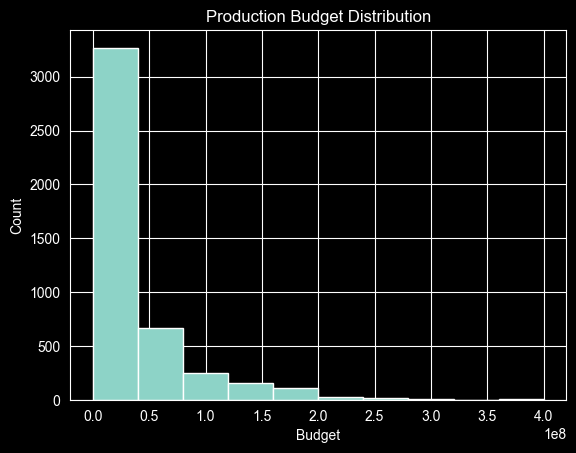

In [26]:
# Convert to numeric temporarily (EDA-safe)
# Production Budget Distribution
# Purpose: Check budget spread and
# identify unrealistic or extreme values

production_budget = pd.to_numeric(
    sales_df["production_budget"],
    errors="coerce"
)

# Plot distribution
production_budget.hist()
plt.title("Production Budget Distribution")
plt.xlabel("Budget")
plt.ylabel("Count")
plt.show()
